In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

PAD_PATH = BASE_PATH / "PAD-UFES-20"
PAD_IMAGE_DIR = PAD_PATH / "images"
PAD_META = PAD_PATH / "metadata.csv"

MODEL_PATH = BASE_PATH / "outputs" / "tinyvit_baseline" / "best_tinyvit.pth"

OUT_DIR = BASE_PATH / "outputs" / "tinyvit_crossdomain_experiments"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 4
CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

print("PAD meta exists:", PAD_META.exists())
print("Model exists:", MODEL_PATH.exists())
print("Output dir:", OUT_DIR)

PAD meta exists: True
Model exists: True
Output dir: E:\Thesis\outputs\tinyvit_crossdomain_experiments


In [3]:
pad = pd.read_csv(PAD_META)

pad_4 = pad[pad["diagnostic"].isin(CLASS_NAMES)].copy()
pad_4["label"] = pad_4["diagnostic"]
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4 = pad_4[pad_4["image_path"].apply(os.path.exists)].copy()

print("PAD samples:", len(pad_4))
print(pad_4["label"].value_counts())

PAD samples: 1871
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [4]:
def resolve_image_dir(folder: Path) -> Path:
    if (folder / "images").exists():
        return folder / "images"
    return folder

In [5]:
def build_df_from_folder(base_df: pd.DataFrame, folder: Path) -> pd.DataFrame:
    df = base_df.copy()
    df["image_path"] = df["img_id"].apply(lambda x: str(folder / x))
    df["exists"] = df["image_path"].apply(os.path.exists)
    df = df[df["exists"]].copy()
    return df

In [6]:
class PADDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        y = self.label_to_idx[label]
        return image, torch.tensor(y, dtype=torch.long)

In [7]:
def make_loader(df: pd.DataFrame, shuffle: bool = False):
    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

    dataset = PADDataset(df, transform=transform)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    return loader

In [8]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = np.eye(len(class_names))[true_classes]
    auc = roc_auc_score(true_onehot, pred_probs, average="macro", multi_class="ovr")

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "report": report,
        "cm": cm,
    }

In [9]:
MODEL_NAME = "tiny_vit_5m_224"

model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=len(CLASS_NAMES)
)

print(model.__class__.__name__)

TinyVit


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded model from model_state_dict.")
elif isinstance(checkpoint, dict):
    try:
        model.load_state_dict(checkpoint)
        print("Loaded model from raw state_dict.")
    except Exception as e:
        raise ValueError(f"Could not load checkpoint as state_dict: {e}")
else:
    raise ValueError("Unsupported checkpoint format.")

model = model.to(device)
model.eval()
print("TinyViT model loaded successfully.")

Loaded model from model_state_dict.
TinyViT model loaded successfully.


In [11]:
experiments = {
    "Original PAD": PAD_IMAGE_DIR,
    "Brightness Normalized PAD": BASE_PATH / "outputs" / "brightness_normalization_test" / "PAD_UFES_20_brightness_normalized_to_HAM",
    "Color Normalized PAD": BASE_PATH / "outputs" / "color_normalization_test" / "PAD_UFES_20_color_normalized_to_HAM",
    "Contrast Normalized PAD": BASE_PATH / "outputs" / "contrast_normalization_test" / "PAD_UFES_20_contrast_normalized_to_HAM",
    "Combined Normalized PAD": BASE_PATH / "outputs" / "combined_normalization_test" / "PAD_UFES_20_combined_normalized_to_HAM",
    "Histogram Matched PAD": BASE_PATH / "PAD_HIST_MATCH_IMPROVED",
    "Histogram + CLAHE PAD": BASE_PATH / "PAD_HIST_CLAHE_IMPROVED",
}

In [12]:
experiment_dfs = {}

for name, folder in experiments.items():
    folder = resolve_image_dir(folder)
    df = build_df_from_folder(pad_4, folder)
    experiment_dfs[name] = df
    print(f"{name}: {len(df)} images | folder: {folder}")

Original PAD: 1871 images | folder: E:\Thesis\PAD-UFES-20\images
Brightness Normalized PAD: 1871 images | folder: E:\Thesis\outputs\brightness_normalization_test\PAD_UFES_20_brightness_normalized_to_HAM
Color Normalized PAD: 1871 images | folder: E:\Thesis\outputs\color_normalization_test\PAD_UFES_20_color_normalized_to_HAM
Contrast Normalized PAD: 1871 images | folder: E:\Thesis\outputs\contrast_normalization_test\PAD_UFES_20_contrast_normalized_to_HAM
Combined Normalized PAD: 1871 images | folder: E:\Thesis\outputs\combined_normalization_test\PAD_UFES_20_combined_normalized_to_HAM
Histogram Matched PAD: 1871 images | folder: E:\Thesis\PAD_HIST_MATCH_IMPROVED
Histogram + CLAHE PAD: 1871 images | folder: E:\Thesis\PAD_HIST_CLAHE_IMPROVED\images


In [13]:
criterion = nn.CrossEntropyLoss()

@torch.inference_mode()
def evaluate_experiment(name: str, df: pd.DataFrame):
    loader = make_loader(df, shuffle=False)

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_preds = []
    all_true = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_true.append(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    metrics = compute_metrics(all_true, all_preds, all_probs, CLASS_NAMES)
    metrics["loss"] = avg_loss
    metrics["true"] = all_true
    metrics["preds"] = all_preds
    metrics["probs"] = all_probs

    print(f"\n=== {name} ===")
    print("Loss :", avg_loss)
    print("Accuracy :", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print("F1 Score :", metrics["f1"])
    print("AUC      :", metrics["auc"])
    print(metrics["report"])

    return metrics

In [14]:
results = {}
confusions = {}

for name, df in experiment_dfs.items():
    if len(df) == 0:
        print(f"Skipping {name} (no images found).")
        continue

    metrics = evaluate_experiment(name, df)
    results[name] = metrics
    confusions[name] = metrics["cm"]


=== Original PAD ===
Loss : 2.7443808862976313
Accuracy : 0.2699091394975949
Precision: 0.3235537831642013
Recall   : 0.35757346287390857
F1 Score : 0.2341184015231744
AUC      : 0.6435385750262367
              precision    recall  f1-score   support

         ACK       0.39      0.18      0.25       730
         BCC       0.59      0.16      0.25       845
         MEL       0.12      0.13      0.13        52
         NEV       0.19      0.96      0.31       244

    accuracy                           0.27      1871
   macro avg       0.32      0.36      0.23      1871
weighted avg       0.45      0.27      0.25      1871


=== Brightness Normalized PAD ===
Loss : 2.7222748807188917
Accuracy : 0.2661678246926777
Precision: 0.3183289686493201
Recall   : 0.3547567327126051
F1 Score : 0.23245489689733406
AUC      : 0.6521725831513148
              precision    recall  f1-score   support

         ACK       0.37      0.16      0.22       730
         BCC       0.57      0.17      0.26  

In [15]:
comparison_rows = []

for name, m in results.items():
    comparison_rows.append({
        "Experiment": name,
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "AUC": m["auc"],
        "Loss": m["loss"],
    })

comparison = pd.DataFrame(comparison_rows)

if "Original PAD" in comparison["Experiment"].values:
    base = comparison.loc[comparison["Experiment"] == "Original PAD"].iloc[0]
    comparison["Accuracy Gain"] = comparison["Accuracy"] - base["Accuracy"]
    comparison["F1 Gain"] = comparison["F1"] - base["F1"]
    comparison["AUC Gain"] = comparison["AUC"] - base["AUC"]
else:
    comparison["Accuracy Gain"] = np.nan
    comparison["F1 Gain"] = np.nan
    comparison["AUC Gain"] = np.nan

comparison = comparison.sort_values("Experiment").reset_index(drop=True)
print(comparison)

comparison.to_csv(OUT_DIR / "tinyvit_crossdomain_comparison.csv", index=False)

                  Experiment  Accuracy  Precision    Recall        F1  \
0  Brightness Normalized PAD  0.266168   0.318329  0.354757  0.232455   
1       Color Normalized PAD  0.335649   0.348758  0.376773  0.274642   
2    Combined Normalized PAD  0.309995   0.327752  0.355022  0.248861   
3    Contrast Normalized PAD  0.256547   0.315527  0.349711  0.223045   
4      Histogram + CLAHE PAD  0.419027   0.362418  0.414646  0.356776   
5      Histogram Matched PAD  0.481026   0.404359  0.468256  0.415161   
6               Original PAD  0.269909   0.323554  0.357573  0.234118   

        AUC      Loss  Accuracy Gain   F1 Gain  AUC Gain  
0  0.652173  2.722275      -0.003741 -0.001664  0.008634  
1  0.664768  2.347998       0.065740  0.040523  0.021230  
2  0.649863  2.498535       0.040086  0.014743  0.006324  
3  0.645173  2.824614      -0.013362 -0.011073  0.001635  
4  0.656609  1.808245       0.149118  0.122657  0.013070  
5  0.708326  1.715810       0.211117  0.181043  0.064788  
6 

In [16]:
summary_dict = {}

for name, m in results.items():
    summary_dict[name] = {
        "accuracy": float(m["accuracy"]),
        "precision": float(m["precision"]),
        "recall": float(m["recall"]),
        "f1": float(m["f1"]),
        "auc": float(m["auc"]),
        "loss": float(m["loss"]),
    }

with open(OUT_DIR / "tinyvit_crossdomain_results.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Saved JSON results.")

Saved JSON results.


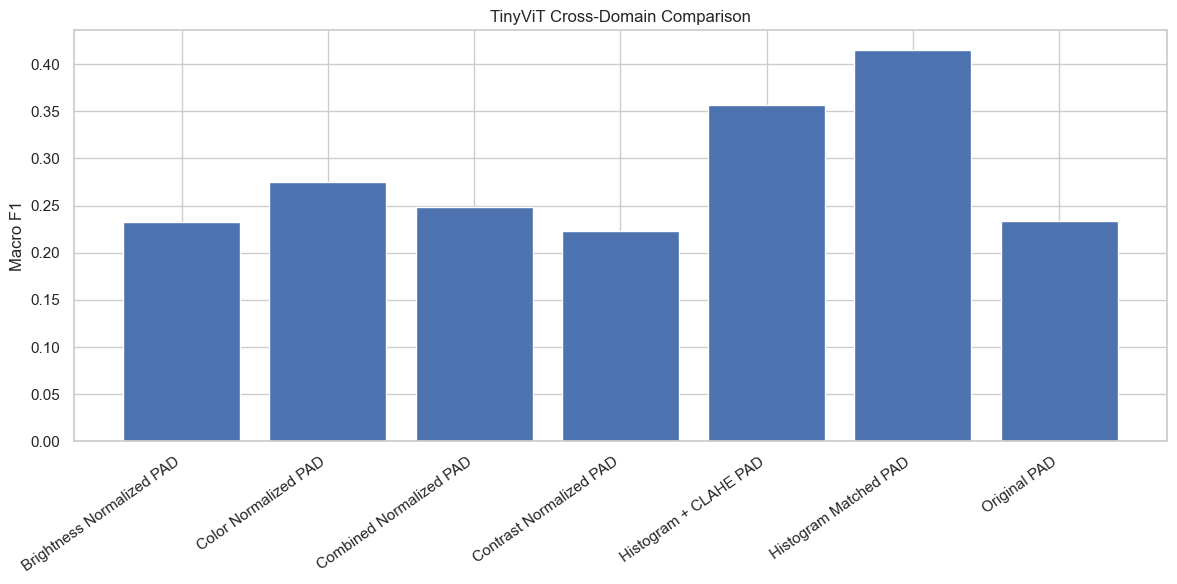

In [17]:
plt.figure(figsize=(12, 6))
plt.bar(comparison["Experiment"], comparison["F1"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Macro F1")
plt.title("TinyViT Cross-Domain Comparison")
plt.tight_layout()
plt.savefig(OUT_DIR / "tinyvit_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

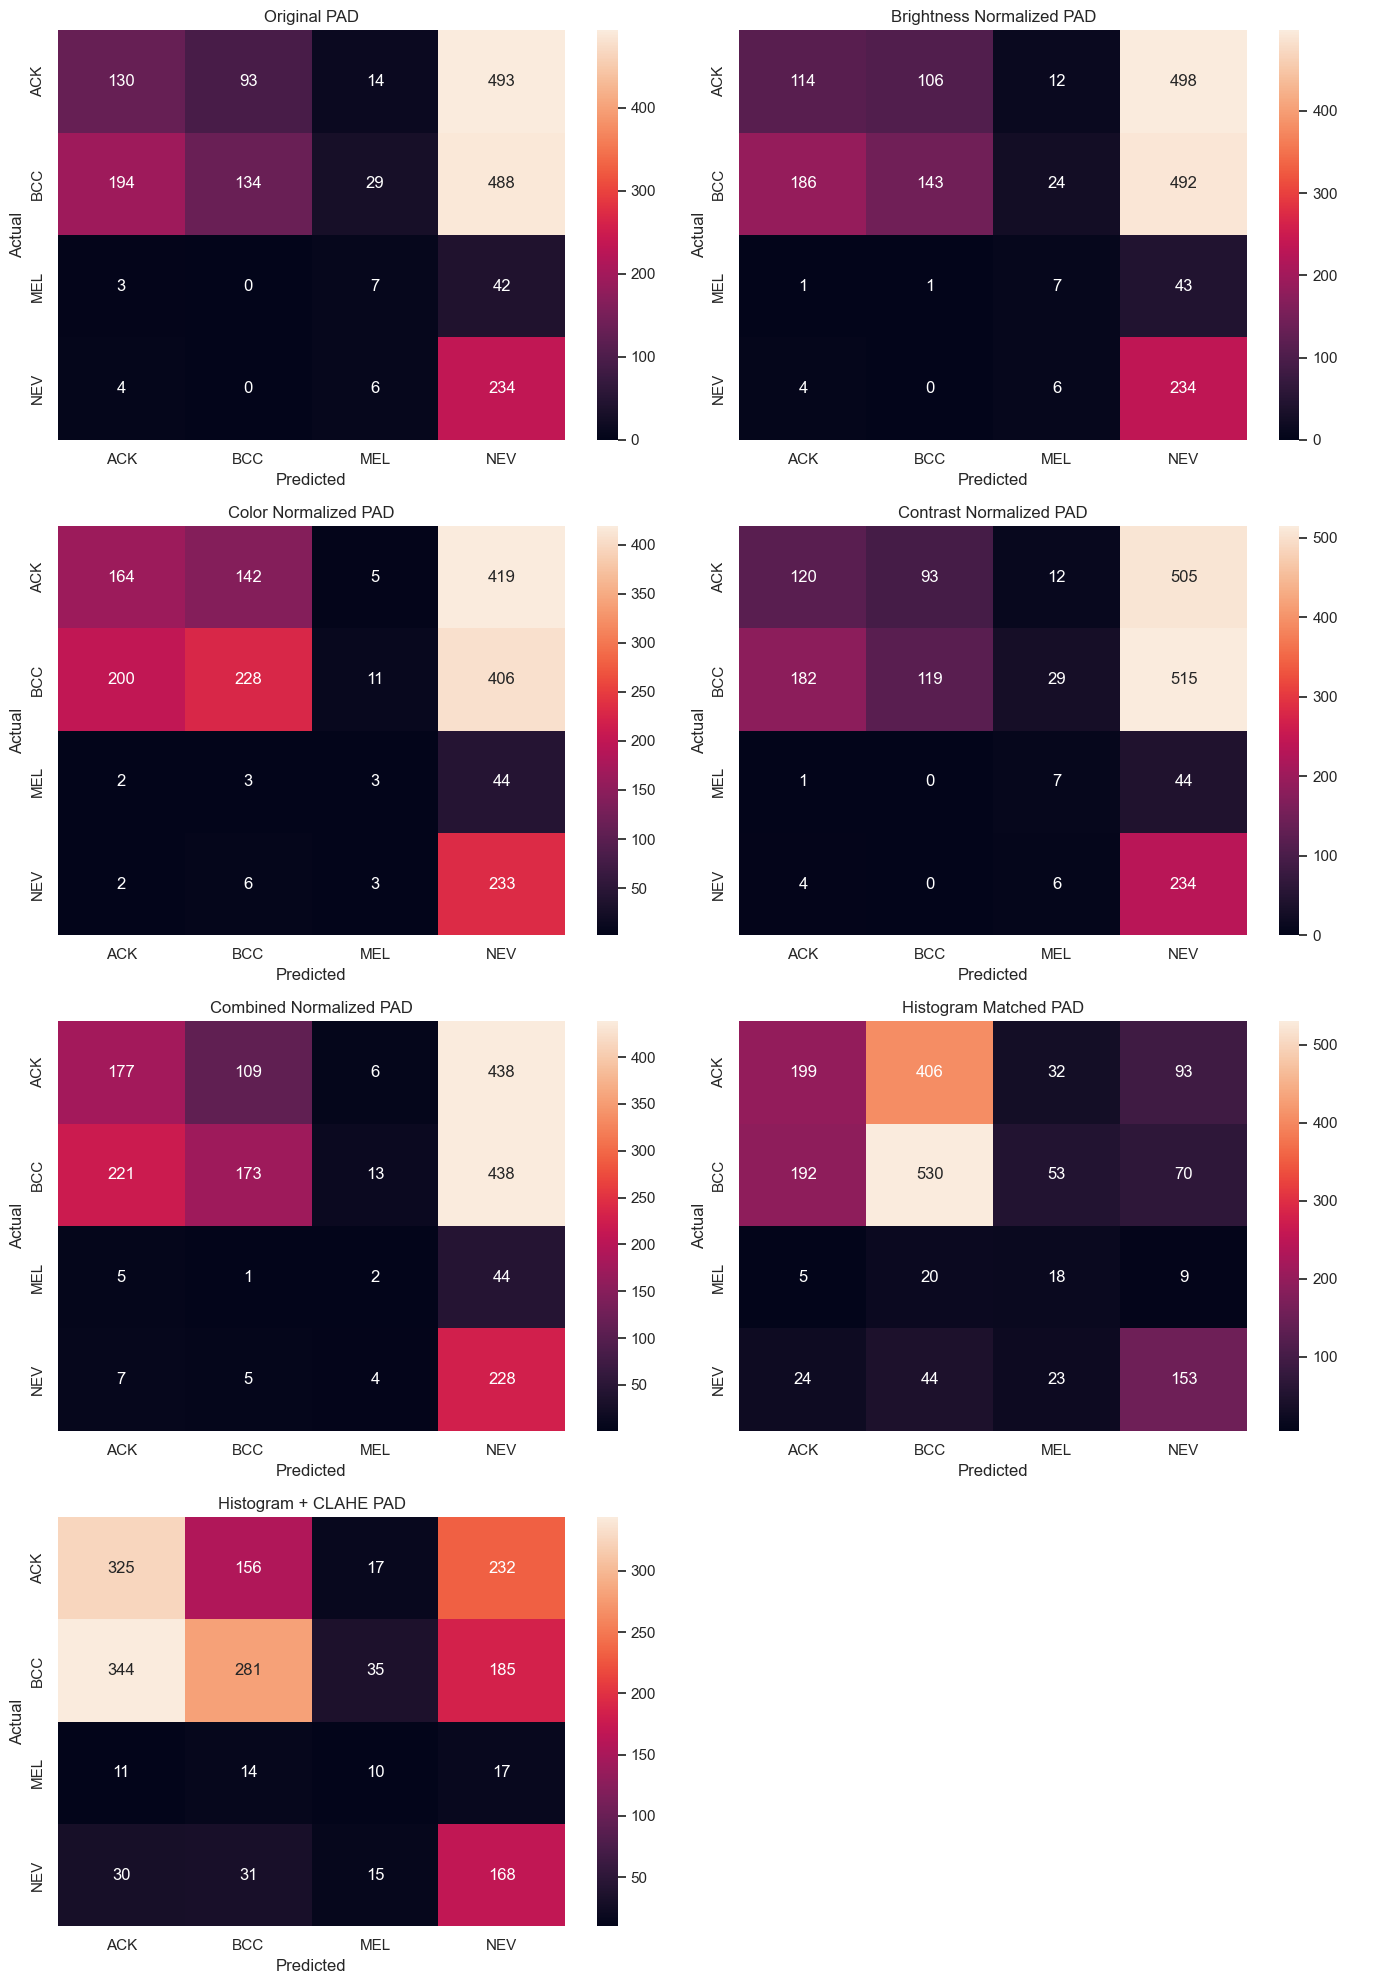

In [18]:
n = len(confusions)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax in axes[n:]:
    ax.axis("off")

for ax, (name, cm) in zip(axes, confusions.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "tinyvit_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
print("\n--- TinyViT CROSS-DOMAIN SUMMARY ---")
for name, m in results.items():
    print(f"{name}: Accuracy={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['auc']:.4f}")


--- TinyViT CROSS-DOMAIN SUMMARY ---
Original PAD: Accuracy=0.2699, F1=0.2341, AUC=0.6435
Brightness Normalized PAD: Accuracy=0.2662, F1=0.2325, AUC=0.6522
Color Normalized PAD: Accuracy=0.3356, F1=0.2746, AUC=0.6648
Contrast Normalized PAD: Accuracy=0.2565, F1=0.2230, AUC=0.6452
Combined Normalized PAD: Accuracy=0.3100, F1=0.2489, AUC=0.6499
Histogram Matched PAD: Accuracy=0.4810, F1=0.4152, AUC=0.7083
Histogram + CLAHE PAD: Accuracy=0.4190, F1=0.3568, AUC=0.6566
